# 09. External Test, Moderation Policy, and App Artifacts

Notebook này là bước **system integration** cho project. Không train lại model, không tạo lại augmented/noisy data.

Mục tiêu:
- Dùng PhoBERT artifact đã train ở Note 8b.
- Chạy pipeline end-to-end trên external/demo comments.
- Tạo toxic-span explanation deployable.
- Tính risk score và moderation action minh bạch.
- Xuất `src/*.py`, `outputs/resources/*.json`, `outputs/results/note09/*.csv` để app Streamlit dùng trực tiếp.

Lưu ý: external/demo set trong notebook này là **qualitative moderation analysis**, không phải benchmark accuracy có nhãn chuẩn.

In [1]:
# 1. Install dependencies
import sys
import subprocess
import importlib.util

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "torch",
    "transformers",
    "sentencepiece",
    "safetensors",
    "underthesea",
]

missing = []
for pkg in packages:
    mod_name = {
        "scikit-learn": "sklearn",
        "sentencepiece": "sentencepiece",
        "safetensors": "safetensors",
    }.get(pkg, pkg)
    if importlib.util.find_spec(mod_name) is None:
        missing.append(pkg)

if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are available.")

Installing: ['underthesea']


In [2]:
# 2. Mount Drive and set project paths
from google.colab import drive
from pathlib import Path
from datetime import datetime
import json
import os
import shutil
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

drive.mount("/content/drive", force_remount=True)

PROJECT_ROOT = Path("/content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification")
assert PROJECT_ROOT.exists(), f"PROJECT_ROOT does not exist: {PROJECT_ROOT}"

DATA_DIR = PROJECT_ROOT / "data"
EXTERNAL_DIR = DATA_DIR / "external"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
RESOURCES_DIR = OUTPUTS_DIR / "resources"
RESULTS_DIR = OUTPUTS_DIR / "results" / "note09"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "note09"
MODELS_DIR = OUTPUTS_DIR / "models"
SRC_DIR = PROJECT_ROOT / "src"

for d in [EXTERNAL_DIR, RESOURCES_DIR, RESULTS_DIR, FIGURES_DIR, SRC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("SRC_DIR:", SRC_DIR)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification
RESULTS_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/note09
FIGURES_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/figures/note09
SRC_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/src


In [3]:
# 3. Validate required model artifact from Note 8b
PHOBERT_MODEL_DIR = MODELS_DIR / "note08b" / "phobert_augmented_mixed"

required_model_files = [
    PHOBERT_MODEL_DIR / "config.json",
]
weight_files = [
    PHOBERT_MODEL_DIR / "model.safetensors",
    PHOBERT_MODEL_DIR / "pytorch_model.bin",
]
tokenizer_files = [
    PHOBERT_MODEL_DIR / "vocab.txt",
    PHOBERT_MODEL_DIR / "bpe.codes",
    PHOBERT_MODEL_DIR / "tokenizer_config.json",
]

print("PHOBERT_MODEL_DIR:", PHOBERT_MODEL_DIR)
print("exists:", PHOBERT_MODEL_DIR.exists())
print("files:", sorted([p.name for p in PHOBERT_MODEL_DIR.iterdir()]) if PHOBERT_MODEL_DIR.exists() else [])

assert PHOBERT_MODEL_DIR.exists(), f"Missing PhoBERT model folder: {PHOBERT_MODEL_DIR}"
for p in required_model_files:
    assert p.exists(), f"Missing required model file: {p}"
assert any(p.exists() for p in weight_files), "Missing model weight: model.safetensors or pytorch_model.bin"
assert any(p.exists() for p in tokenizer_files), "Missing tokenizer files in PhoBERT model folder"

print("PhoBERT artifact is valid.")

PHOBERT_MODEL_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/models/note08b/phobert_augmented_mixed
exists: True
files: ['added_tokens.json', 'bpe.codes', 'config.json', 'model.safetensors', 'tokenizer_config.json', 'training_meta.json', 'vocab.txt']
PhoBERT artifact is valid.


In [4]:
# 4. Load project normalization with a safe fallback
import importlib.util
import re
import unicodedata


def load_project_normalize_text(project_root: Path):
    norm_path = project_root / "src" / "normalization.py"
    if not norm_path.exists():
        print("No src/normalization.py found. Use fallback normalization.")
        return None, "fallback"
    try:
        spec = importlib.util.spec_from_file_location("project_normalization", str(norm_path))
        if spec is None or spec.loader is None:
            return None, "fallback"
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        fn = getattr(mod, "normalize_text", None)
        if callable(fn):
            print("Loaded normalize_text from:", norm_path)
            return fn, str(norm_path.relative_to(project_root))
        print("src/normalization.py exists but normalize_text is not callable. Use fallback.")
        return None, "fallback"
    except Exception as exc:
        print("Could not load src/normalization.py. Use fallback. Error:", repr(exc))
        return None, "fallback"


def fallback_normalize_text(text: str) -> str:
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"(?<=\w)[\.\*_\-]+(?=\w)", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    replacements = {
        "ko": "không", "k": "không", "khong": "không", "hok": "không", "hong": "không",
        "dc": "được", "đc": "được", "j": "gì", "gj": "gì",
        "vl": "vãi", "vcl": "vãi", "vc": "vãi", "dm": "đm", "dmm": "đm",
    }
    toks = []
    for tok in text.split():
        toks.append(replacements.get(tok.lower(), tok))
    return " ".join(toks)


PROJECT_NORMALIZE_TEXT, NORMALIZATION_SOURCE = load_project_normalize_text(PROJECT_ROOT)


def normalize_text(text: str) -> str:
    if PROJECT_NORMALIZE_TEXT is not None:
        try:
            return str(PROJECT_NORMALIZE_TEXT(text))
        except Exception:
            return fallback_normalize_text(text)
    return fallback_normalize_text(text)


for s in ["mày nguuuuu vl", "m.à.y n*g*u", "ko thích cách nói này"]:
    print(s, "=>", normalize_text(s))

src/normalization.py exists but normalize_text is not callable. Use fallback.
mày nguuuuu vl => mày nguu vãi
m.à.y n*g*u => mày ngu
ko thích cách nói này => không thích cách nói này


In [5]:
# 5. Write reusable backend modules for the Streamlit app
from datetime import datetime
import ast

MODULES = {
    "app_utils.py": '\nfrom __future__ import annotations\n\nimport json\nimport os\nfrom pathlib import Path\nfrom typing import Any\n\n\ndef find_project_root() -> Path:\n    env_root = os.environ.get("PROJECT_ROOT")\n    candidates = []\n    if env_root:\n        candidates.append(Path(env_root))\n    candidates.extend([\n        Path("/content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification"),\n        Path.cwd(),\n    ])\n    for c in candidates:\n        if (c / "data").exists() and (c / "outputs").exists():\n            return c.resolve()\n    return candidates[0].resolve() if candidates else Path.cwd().resolve()\n\n\ndef ensure_dir(path: str | Path) -> Path:\n    p = Path(path)\n    p.mkdir(parents=True, exist_ok=True)\n    return p\n\n\ndef read_json(path: str | Path, default: Any = None) -> Any:\n    p = Path(path)\n    if not p.exists():\n        return default\n    return json.loads(p.read_text(encoding="utf-8"))\n\n\ndef write_json(obj: Any, path: str | Path) -> Path:\n    p = Path(path)\n    p.parent.mkdir(parents=True, exist_ok=True)\n    p.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")\n    return p\n\n\ndef safe_json_dumps(obj: Any) -> str:\n    return json.dumps(obj, ensure_ascii=False)\n',
    "risk_scoring.py": '\nfrom __future__ import annotations\n\nfrom typing import Any, Dict, Sequence\n\nimport numpy as np\n\n\nBASE_LABEL_RISK = {\n    "CLEAN": 0.10,\n    "OFFENSIVE": 0.55,\n    "HATE": 0.85,\n}\n\nPOLICY_ADJUSTMENT = {\n    "lenient": -0.05,\n    "balanced": 0.00,\n    "strict": 0.05,\n}\n\n\ndef risk_level_from_score(score: float) -> str:\n    score = float(score)\n    if score < 0.30:\n        return "low"\n    if score < 0.60:\n        return "medium"\n    if score < 0.80:\n        return "high"\n    return "critical"\n\n\ndef compute_risk_score(\n    predicted_label: str,\n    confidence: float,\n    prob_offensive: float = 0.0,\n    prob_hate: float = 0.0,\n    toxic_spans: Sequence[Dict[str, Any]] | None = None,\n    text_changed_by_normalization: bool = False,\n    policy_mode: str = "balanced",\n) -> Dict[str, Any]:\n    label = str(predicted_label).upper()\n    conf = float(confidence or 0.0)\n    prob_offensive = float(prob_offensive or 0.0)\n    prob_hate = float(prob_hate or 0.0)\n    spans = list(toxic_spans or [])\n\n    base = BASE_LABEL_RISK.get(label, 0.25)\n    confidence_bonus = max(0.0, conf - 0.50) * 0.20\n    hate_probability_bonus = prob_hate * 0.08\n    offensive_probability_bonus = prob_offensive * 0.04\n    span_count_bonus = min(0.18, len(spans) * 0.05)\n    span_length_bonus = min(0.07, sum(len(str(s.get("text", ""))) for s in spans) / 200.0)\n    normalization_bonus = 0.03 if bool(text_changed_by_normalization) and label != "CLEAN" else 0.0\n    policy_adjustment = POLICY_ADJUSTMENT.get(policy_mode, 0.0)\n\n    score = float(np.clip(\n        base + confidence_bonus + hate_probability_bonus + offensive_probability_bonus\n        + span_count_bonus + span_length_bonus + normalization_bonus + policy_adjustment,\n        0.0,\n        1.0,\n    ))\n\n    components = {\n        "base_label_risk": round(base, 4),\n        "confidence_bonus": round(confidence_bonus, 4),\n        "hate_probability_bonus": round(hate_probability_bonus, 4),\n        "offensive_probability_bonus": round(offensive_probability_bonus, 4),\n        "span_count_bonus": round(span_count_bonus, 4),\n        "span_length_bonus": round(span_length_bonus, 4),\n        "normalization_bonus": round(normalization_bonus, 4),\n        "policy_adjustment": round(policy_adjustment, 4),\n        "final_risk": round(score, 4),\n    }\n    return {\n        "risk_score": score,\n        "risk_level": risk_level_from_score(score),\n        "risk_components": components,\n    }\n',
    "moderation.py": '\nfrom __future__ import annotations\n\nfrom typing import Dict\n\nACTION_TABLE: Dict[str, Dict[str, str]] = {\n    "lenient": {\n        "low": "allow",\n        "medium": "allow_with_note",\n        "high": "warn_user",\n        "critical": "send_to_review",\n    },\n    "balanced": {\n        "low": "allow",\n        "medium": "warn_user",\n        "high": "send_to_review",\n        "critical": "block_or_escalate",\n    },\n    "strict": {\n        "low": "allow",\n        "medium": "send_to_review",\n        "high": "hide_comment",\n        "critical": "block_or_escalate",\n    },\n}\n\n\ndef moderation_decision(risk_level: str, policy_mode: str = "balanced") -> str:\n    return ACTION_TABLE.get(policy_mode, ACTION_TABLE["balanced"]).get(str(risk_level), "send_to_review")\n\n\ndef build_reason(\n    predicted_label: str,\n    confidence: float,\n    toxic_span_texts: list[str],\n    risk_level: str,\n    action: str,\n    text_changed_by_normalization: bool = False,\n) -> str:\n    label = str(predicted_label).upper()\n    conf = float(confidence or 0.0)\n    if label == "CLEAN" and not toxic_span_texts:\n        return "Predicted as CLEAN and no toxic span was found."\n\n    parts = [f"Predicted as {label} with confidence {conf:.2f}."]\n    if toxic_span_texts:\n        parts.append("Detected toxic span(s): " + ", ".join(toxic_span_texts[:5]) + ".")\n    if text_changed_by_normalization:\n        parts.append("Normalization changed the text, suggesting noisy or obfuscated input.")\n    parts.append(f"Risk level is {risk_level}; suggested action is {action}.")\n    return " ".join(parts)\n',
    "span_explainer.py": '\nfrom __future__ import annotations\n\nimport html\nimport json\nimport re\nfrom pathlib import Path\nfrom typing import Any, Dict, List, Sequence, Tuple\n\nimport pandas as pd\n\n\ndef _collect_strings(obj: Any) -> List[str]:\n    out: List[str] = []\n    if isinstance(obj, str):\n        out.append(obj)\n    elif isinstance(obj, dict):\n        for v in obj.values():\n            out.extend(_collect_strings(v))\n    elif isinstance(obj, list):\n        for v in obj:\n            out.extend(_collect_strings(v))\n    return out\n\n\ndef load_toxic_phrases(project_root: str | Path, max_phrases: int = 2000) -> List[str]:\n    root = Path(project_root)\n    phrases: List[str] = []\n\n    json_candidates = [\n        root / "outputs" / "resources" / "toxic_span_highlighter_rules.json",\n        root / "outputs" / "resources" / "span_explainer_config.json",\n    ]\n    for path in json_candidates:\n        if path.exists():\n            try:\n                data = json.loads(path.read_text(encoding="utf-8"))\n                phrases.extend(_collect_strings(data))\n            except Exception:\n                pass\n\n    csv_candidates = [\n        root / "outputs" / "resources" / "toxic_phrases_candidates_train.csv",\n        root / "outputs" / "resources" / "toxic_phrases_candidates.csv",\n    ]\n    for path in csv_candidates:\n        if path.exists():\n            try:\n                df = pd.read_csv(path)\n                text_cols = [c for c in df.columns if c.lower() in {"phrase", "text", "span", "toxic_phrase"}]\n                if not text_cols:\n                    text_cols = [df.columns[0]]\n                phrases.extend(df[text_cols[0]].dropna().astype(str).tolist())\n            except Exception:\n                pass\n\n    fallback = [\n        "ngu", "đồ ngu", "óc chó", "đồ chó", "cút", "đm", "đmm", "vãi", "khốn",\n        "đồ điên", "chó chết", "mất dạy", "rác rưởi", "súc vật", "đồ khùng",\n    ]\n    phrases.extend(fallback)\n\n    cleaned = []\n    for p in phrases:\n        p = str(p).strip().lower()\n        if 2 <= len(p) <= 40 and not p.endswith(".json") and "/" not in p and "\\\\" not in p:\n            cleaned.append(p)\n    return sorted(set(cleaned), key=len, reverse=True)[:max_phrases]\n\n\ndef extract_toxic_spans(text: str, phrases: Sequence[str]) -> List[Dict[str, Any]]:\n    text = str(text)\n    lower = text.lower()\n    spans: List[Dict[str, Any]] = []\n    occupied: List[Tuple[int, int]] = []\n\n    for phrase in phrases:\n        phrase = str(phrase).strip().lower()\n        if not phrase:\n            continue\n        for m in re.finditer(re.escape(phrase), lower):\n            start, end = m.start(), m.end()\n            if any(not (end <= s or start >= e) for s, e in occupied):\n                continue\n            spans.append({\n                "start": start,\n                "end": end,\n                "text": text[start:end],\n                "source": "rule",\n                "score": 0.85,\n            })\n            occupied.append((start, end))\n    spans.sort(key=lambda s: int(s.get("start", 0)))\n    return spans\n\n\ndef highlight_text(text: str, spans: Sequence[Dict[str, Any]]) -> str:\n    text = str(text)\n    if not spans:\n        return html.escape(text)\n\n    parts: List[str] = []\n    last = 0\n    for sp in sorted(spans, key=lambda x: int(x.get("start", 0))):\n        start = max(0, int(sp.get("start", 0)))\n        end = min(len(text), int(sp.get("end", start)))\n        if start < last or end <= start:\n            continue\n        parts.append(html.escape(text[last:start]))\n        parts.append(\n            "<mark style=\'background-color:#ffdddd;border:1px solid #ff9999;"\n            "padding:2px 4px;border-radius:4px;\'>"\n            + html.escape(text[start:end])\n            + "</mark>"\n        )\n        last = end\n    parts.append(html.escape(text[last:]))\n    return "".join(parts)\n',
    "inference.py": '\nfrom __future__ import annotations\n\nimport importlib.util\nimport os\nimport re\nimport unicodedata\nfrom pathlib import Path\nfrom typing import Any, Dict, List, Sequence\n\nimport numpy as np\nimport pandas as pd\n\ntry:\n    import torch\n    from transformers import AutoModelForSequenceClassification, AutoTokenizer\nexcept Exception as exc:  # pragma: no cover\n    torch = None\n    AutoModelForSequenceClassification = None\n    AutoTokenizer = None\n    TRANSFORMERS_IMPORT_ERROR = exc\nelse:\n    TRANSFORMERS_IMPORT_ERROR = None\n\nLABEL_FALLBACK = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}\nMAX_LENGTH = 128\n\n\ndef _has_transformer_weights(path: Path) -> bool:\n    if not path.is_dir():\n        return False\n    has_config = (path / "config.json").exists()\n    has_weight = any((path / name).exists() for name in [\n        "pytorch_model.bin", "model.safetensors", "tf_model.h5", "flax_model.msgpack"\n    ])\n    return has_config and has_weight\n\n\ndef find_phobert_model_dir(project_root: str | Path) -> Path | None:\n    root = Path(project_root)\n    candidates = [\n        root / "outputs" / "models" / "note08b" / "phobert_augmented_mixed",\n        root / "outputs" / "models" / "note08b" / "phobert_augmented",\n        root / "outputs" / "models" / "note08b" / "phobert_augmented_best",\n        root / "outputs" / "models" / "note08b_v2" / "phobert_augmented_mixed",\n        root / "outputs" / "models" / "note08b_v2" / "phobert_augmented",\n        root / "outputs" / "models" / "phobert_augmented",\n        root / "outputs" / "models" / "phobert",\n        root / "outputs" / "models" / "phobert_model",\n        root / "outputs" / "models" / "best_phobert",\n        root / "models" / "phobert",\n    ]\n    for c in candidates:\n        if _has_transformer_weights(c):\n            return c\n\n    found: List[Path] = []\n    for search_root in [root / "outputs" / "models", root / "models"]:\n        if search_root.exists():\n            for config_path in search_root.rglob("config.json"):\n                d = config_path.parent\n                if _has_transformer_weights(d) and "phobert" in str(d).lower():\n                    found.append(d)\n    if not found:\n        return None\n    return sorted(found, key=lambda p: ("note08b" not in str(p).lower(), len(str(p))))[0]\n\n\ndef _load_project_normalize_text(project_root: Path):\n    norm_path = project_root / "src" / "normalization.py"\n    if not norm_path.exists():\n        return None\n    try:\n        spec = importlib.util.spec_from_file_location("project_normalization", str(norm_path))\n        if spec is None or spec.loader is None:\n            return None\n        mod = importlib.util.module_from_spec(spec)\n        spec.loader.exec_module(mod)\n        fn = getattr(mod, "normalize_text", None)\n        if callable(fn):\n            return fn\n    except Exception:\n        return None\n    return None\n\n\ndef fallback_normalize_text(text: str) -> str:\n    text = str(text)\n    text = unicodedata.normalize("NFC", text)\n    text = re.sub(r"(.)\\1{2,}", r"\\1\\1", text)\n    text = re.sub(r"(?<=\\w)[\\.\\*_\\-]+(?=\\w)", "", text)\n    text = re.sub(r"\\s+", " ", text).strip()\n    replacements = {\n        "ko": "không", "k": "không", "khong": "không", "hok": "không", "hong": "không",\n        "dc": "được", "đc": "được", "j": "gì", "gj": "gì",\n        "vl": "vãi", "vcl": "vãi", "vc": "vãi", "dm": "đm", "dmm": "đm",\n    }\n    return " ".join(replacements.get(tok.lower(), tok) for tok in text.split())\n\n\ndef normalize_text(text: str, project_root: str | Path | None = None) -> str:\n    if project_root is not None:\n        fn = _load_project_normalize_text(Path(project_root))\n        if fn is not None:\n            try:\n                return str(fn(text))\n            except Exception:\n                pass\n    return fallback_normalize_text(text)\n\n\ndef get_segmenter_name() -> str:\n    try:\n        import underthesea  # noqa: F401\n        return "underthesea"\n    except Exception:\n        pass\n    try:\n        import pyvi  # noqa: F401\n        return "pyvi"\n    except Exception:\n        pass\n    return "none"\n\n\ndef segment_vietnamese(text: str) -> str:\n    text = str(text)\n    name = get_segmenter_name()\n    if name == "underthesea":\n        try:\n            from underthesea import word_tokenize\n            return str(word_tokenize(text, format="text"))\n        except Exception:\n            return text\n    if name == "pyvi":\n        try:\n            from pyvi import ViTokenizer\n            return str(ViTokenizer.tokenize(text))\n        except Exception:\n            return text\n    return text\n\n\ndef normalize_label(label: str) -> str:\n    s = str(label).upper()\n    if s in {"0", "LABEL_0"}:\n        return "CLEAN"\n    if s in {"1", "LABEL_1"}:\n        return "OFFENSIVE"\n    if s in {"2", "LABEL_2"}:\n        return "HATE"\n    if "CLEAN" in s:\n        return "CLEAN"\n    if "OFF" in s:\n        return "OFFENSIVE"\n    if "HATE" in s:\n        return "HATE"\n    return s\n\n\ndef load_full_phobert(model_dir: str | Path):\n    if TRANSFORMERS_IMPORT_ERROR is not None:\n        raise RuntimeError(f"Cannot import torch/transformers: {TRANSFORMERS_IMPORT_ERROR}")\n    model_dir = Path(model_dir)\n    if not _has_transformer_weights(model_dir):\n        raise FileNotFoundError(f"Invalid PhoBERT model folder: {model_dir}")\n\n    try:\n        tokenizer = AutoTokenizer.from_pretrained(str(model_dir), use_fast=False)\n    except Exception:\n        tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)\n\n    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir))\n    model.eval()\n    device = "cuda" if torch.cuda.is_available() else "cpu"\n    model.to(device)\n\n    raw = getattr(model.config, "id2label", None) or LABEL_FALLBACK\n    id2label = {int(k): normalize_label(v) for k, v in dict(raw).items()}\n    for i, label in LABEL_FALLBACK.items():\n        id2label.setdefault(i, label)\n    return tokenizer, model, device, id2label\n\n\ndef predict_texts(\n    texts: Sequence[str],\n    tokenizer: Any,\n    model: Any,\n    device: str,\n    id2label: Dict[int, str],\n    project_root: str | Path | None = None,\n    normalize_input: bool = True,\n    batch_size: int = 16,\n    max_length: int = MAX_LENGTH,\n) -> pd.DataFrame:\n    rows: List[Dict[str, Any]] = []\n    label_order = [id2label.get(i, LABEL_FALLBACK.get(i, f"LABEL_{i}")) for i in range(3)]\n\n    for start in range(0, len(texts), batch_size):\n        raw_batch = [str(x) for x in texts[start:start + batch_size]]\n        norm_batch = [normalize_text(x, project_root=project_root) if normalize_input else x for x in raw_batch]\n        seg_batch = [segment_vietnamese(x) for x in norm_batch]\n        enc = tokenizer(seg_batch, truncation=True, padding=True, max_length=max_length, return_tensors="pt")\n        enc = {k: v.to(device) for k, v in enc.items()}\n        with torch.no_grad():\n            logits = model(**enc).logits\n            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()\n        for raw_text, norm_text, prob in zip(raw_batch, norm_batch, probs):\n            pred_id = int(np.argmax(prob))\n            row = {\n                "original_text": raw_text,\n                "normalized_text": norm_text,\n                "text_changed_by_normalization": raw_text.strip() != norm_text.strip(),\n                "predicted_label": id2label.get(pred_id, f"LABEL_{pred_id}"),\n                "confidence": float(prob[pred_id]),\n            }\n            for i, label in enumerate(label_order):\n                row[f"prob_{str(label).lower()}"] = float(prob[i]) if i < len(prob) else np.nan\n            rows.append(row)\n    return pd.DataFrame(rows)\n',
}

backup_dir = SRC_DIR / ("_backup_note09_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
backup_dir.mkdir(parents=True, exist_ok=True)

written_files = []
for filename, content in MODULES.items():
    target = SRC_DIR / filename
    ast.parse(content, filename=filename)
    if target.exists():
        shutil.copy2(target, backup_dir / filename)
    target.write_text(content, encoding="utf-8")
    written_files.append(target)
    print("Wrote:", target.relative_to(PROJECT_ROOT))

print("Backup folder:", backup_dir.relative_to(PROJECT_ROOT))

Wrote: src/app_utils.py
Wrote: src/risk_scoring.py
Wrote: src/moderation.py
Wrote: src/span_explainer.py
Wrote: src/inference.py
Backup folder: src/_backup_note09_20260610_123042


In [6]:
# 6. Import newly written backend modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.inference import find_phobert_model_dir, load_full_phobert, predict_texts
from src.span_explainer import load_toxic_phrases, extract_toxic_spans, highlight_text
from src.risk_scoring import compute_risk_score
from src.moderation import moderation_decision, build_reason
from src.app_utils import write_json, safe_json_dumps

found_model_dir = find_phobert_model_dir(PROJECT_ROOT)
print("Detected PhoBERT model:", found_model_dir)
assert found_model_dir == PHOBERT_MODEL_DIR, f"Expected {PHOBERT_MODEL_DIR}, got {found_model_dir}"

Detected PhoBERT model: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/models/note08b/phobert_augmented_mixed


In [7]:
# 7. Create or load external qualitative demo comments
EXTERNAL_COMMENTS_PATH = EXTERNAL_DIR / "external_comments.csv"
RECREATE_EXTERNAL_COMMENTS = False

examples = [
    ("ex001", "Bạn nói chuyện rất dễ thương, cảm ơn nhé.", "clean", "allow", "positive clean comment"),
    ("ex002", "Mình không đồng ý với quan điểm này nhưng vẫn tôn trọng bạn.", "clean", "allow", "polite disagreement"),
    ("ex003", "Bài viết này cần thêm bằng chứng chứ đừng kết luận vội.", "clean", "allow", "critical but non-toxic"),
    ("ex004", "Tôi thấy cách diễn đạt hơi khó hiểu.", "clean", "allow", "neutral feedback"),
    ("ex005", "Cảm ơn bạn đã chia sẻ thông tin.", "clean", "allow", "clean"),
    ("ex006", "Cái này sai rồi, bạn kiểm tra lại giúp mình.", "clean", "allow", "non-toxic correction"),
    ("ex007", "Mày nói chuyện ngu thật.", "offensive", "warn_or_review", "direct insult"),
    ("ex008", "Đồ ngu, đọc lại đi rồi hãy nói.", "offensive", "warn_or_review", "direct insult"),
    ("ex009", "Cút đi, đừng bình luận nữa.", "offensive", "warn_or_review", "dismissive abuse"),
    ("ex010", "Nói chuyện mất dạy quá.", "offensive", "warn_or_review", "offensive phrase"),
    ("ex011", "Bớt xàm đi, nghe mệt thật sự.", "offensive", "warn_or_review", "mild insult"),
    ("ex012", "Đừng có làm trò rác rưởi ở đây.", "offensive", "warn_or_review", "abusive phrase"),
    ("ex013", "Mày đúng là đồ điên.", "offensive", "warn_or_review", "direct insult"),
    ("ex014", "Cái kiểu nói chuyện này thật khốn.", "offensive", "warn_or_review", "abusive phrase"),
    ("ex015", "Tao không muốn nghe mày nói nữa.", "offensive", "warn_or_review", "aggressive tone"),
    ("ex016", "Đồ chó chết, biến đi.", "abusive", "block_or_escalate", "strong abuse"),
    ("ex017", "Mày là thứ rác rưởi.", "abusive", "block_or_escalate", "strong abuse"),
    ("ex018", "Đúng là súc vật mới nói vậy.", "abusive", "block_or_escalate", "dehumanizing abuse"),
    ("ex019", "Nói vậy mà cũng nói được, óc chó thật.", "abusive", "block_or_escalate", "strong insult"),
    ("ex020", "Đừng xuất hiện ở đây nữa, đồ khốn.", "abusive", "block_or_escalate", "strong abuse"),
    ("ex021", "may noi chuyen ngu that", "no_accent", "normalize_then_flag", "no accent offensive"),
    ("ex022", "do ngu doc lai di", "no_accent", "normalize_then_flag", "no accent insult"),
    ("ex023", "cut di dung binh luan nua", "no_accent", "normalize_then_flag", "no accent abuse"),
    ("ex024", "noi chuyen mat day qua", "no_accent", "normalize_then_flag", "no accent offensive"),
    ("ex025", "bai viet nay rat hay cam on ban", "no_accent_clean", "allow", "no accent clean"),
    ("ex026", "mày nguuuuu vl", "repeated_char", "normalize_then_flag", "repeated character toxic"),
    ("ex027", "đồ chóooo chết", "repeated_char", "normalize_then_flag", "repeated character abusive"),
    ("ex028", "cútttt đi", "repeated_char", "normalize_then_flag", "repeated character offensive"),
    ("ex029", "bạn dễ thương quáaaa", "repeated_char_clean", "allow", "repeated char clean"),
    ("ex030", "m.à.y n*g*u vl", "special_mask", "normalize_then_flag", "masked offensive"),
    ("ex031", "đ.ồ ch.ó ch.ết", "special_mask", "normalize_then_flag", "masked abuse"),
    ("ex032", "c_u_t đi", "special_mask", "normalize_then_flag", "masked offensive"),
    ("ex033", "bạn nói rất h.a.y", "special_mask_clean", "allow", "masked clean"),
    ("ex034", "ko thích cái kiểu nói chuyện này", "teencode", "allow_or_warn", "teencode mild"),
    ("ex035", "m nói ngu vl", "teencode", "warn_or_review", "teencode offensive"),
    ("ex036", "t thấy bạn hơi quá lời", "teencode_clean", "allow", "teencode clean"),
    ("ex037", "may nguuuu vl do cho", "mixed_noise", "normalize_then_flag", "mixed toxic"),
    ("ex038", "d.o n.g.u c.ut di", "mixed_noise", "normalize_then_flag", "mixed masked toxic"),
    ("ex039", "ko co gi dau ban noi tiep di", "mixed_noise_clean", "allow", "mixed clean"),
    ("ex040", "Bạn giỏi quá ha, nói câu nào cũng sai.", "ambiguous", "review_if_uncertain", "sarcasm borderline"),
    ("ex041", "Không biết nên cười hay khóc với ý kiến này.", "ambiguous", "allow_or_review", "sarcastic but not explicit"),
    ("ex042", "Ý kiến này tệ nhưng mình sẽ không công kích cá nhân.", "ambiguous", "allow", "critical non-toxic"),
    ("ex043", "Bạn nên đọc kỹ hơn trước khi bình luận.", "borderline", "allow", "firm but not toxic"),
    ("ex044", "Nói thật là cách bạn phản hồi hơi khó chịu.", "borderline", "allow_or_warn", "borderline tone"),
    ("ex045", "Đừng spam nữa nhé.", "borderline", "allow", "moderation-like clean"),
    ("ex046", "Spam nữa là mình report đó.", "borderline", "allow_or_warn", "warning but not toxic"),
    ("ex047", "Đồ ngu mà cứ thích thể hiện.", "offensive", "warn_or_review", "direct insult"),
    ("ex048", "Mày đúng là hết thuốc chữa.", "offensive", "warn_or_review", "personal attack"),
    ("ex049", "Chán cái cách nói chuyện vô duyên này.", "borderline", "allow_or_warn", "negative but mild"),
    ("ex050", "Không thích thì góp ý, đừng xúc phạm người khác.", "clean", "allow", "anti-toxic clean"),
    ("ex051", "Bình luận này không phù hợp, nên dừng lại.", "clean", "allow", "moderation clean"),
    ("ex052", "Tao thấy mày nói chuyện rất mất dạy.", "offensive", "warn_or_review", "insult"),
    ("ex053", "Mấy câu này nghe rất khó chịu.", "clean", "allow", "negative clean"),
    ("ex054", "đm nói gì kỳ vậy", "offensive", "warn_or_review", "profanity"),
    ("ex055", "dm noi gi ky vay", "no_accent", "normalize_then_flag", "no accent profanity"),
    ("ex056", "d.m n.o.i g.i k.y", "special_mask", "normalize_then_flag", "masked profanity"),
    ("ex057", "Bạn trình bày thiếu logic nhưng mình hiểu ý chính.", "clean", "allow", "constructive criticism"),
    ("ex058", "Ngu thì im đi.", "offensive", "warn_or_review", "short toxic"),
    ("ex059", "ngu thi im di", "no_accent", "normalize_then_flag", "short no accent toxic"),
    ("ex060", "n.g.u thì im đi", "special_mask", "normalize_then_flag", "short masked toxic"),
    ("ex061", "Mình nghĩ bình luận này có thể gây hiểu lầm.", "clean", "allow", "clean"),
    ("ex062", "Bạn nói vậy là thiếu tôn trọng người khác.", "clean", "allow", "criticism of behavior"),
    ("ex063", "Tắt máy học lại đi.", "offensive", "warn_or_review", "mild insult"),
    ("ex064", "Bớt nói linh tinh lại.", "borderline", "allow_or_warn", "borderline"),
]

if RECREATE_EXTERNAL_COMMENTS or not EXTERNAL_COMMENTS_PATH.exists():
    ext_df = pd.DataFrame(examples, columns=["sample_id", "text", "case_type", "expected_behavior", "note"])
    ext_df.to_csv(EXTERNAL_COMMENTS_PATH, index=False, encoding="utf-8-sig")
    print("Created:", EXTERNAL_COMMENTS_PATH.relative_to(PROJECT_ROOT))
else:
    ext_df = pd.read_csv(EXTERNAL_COMMENTS_PATH)
    print("Loaded existing:", EXTERNAL_COMMENTS_PATH.relative_to(PROJECT_ROOT))

required_cols = {"sample_id", "text", "case_type", "expected_behavior", "note"}
missing = required_cols - set(ext_df.columns)
assert not missing, f"external_comments.csv missing columns: {missing}"

print("Rows:", len(ext_df))
display(ext_df.head(10))

Created: data/external/external_comments.csv
Rows: 64


,sample_id,text,case_type,expected_behavior,note
0,ex001,"Bạn nói chuyện rất dễ thương, cảm ơn nhé.",clean,allow,positive clean comment
1,ex002,Mình không đồng ý với quan điểm này nhưng vẫn ...,clean,allow,polite disagreement
2,ex003,Bài viết này cần thêm bằng chứng chứ đừng kết ...,clean,allow,critical but non-toxic
3,ex004,Tôi thấy cách diễn đạt hơi khó hiểu.,clean,allow,neutral feedback
4,ex005,Cảm ơn bạn đã chia sẻ thông tin.,clean,allow,clean
5,ex006,"Cái này sai rồi, bạn kiểm tra lại giúp mình.",clean,allow,non-toxic correction
6,ex007,Mày nói chuyện ngu thật.,offensive,warn_or_review,direct insult
7,ex008,"Đồ ngu, đọc lại đi rồi hãy nói.",offensive,warn_or_review,direct insult
8,ex009,"Cút đi, đừng bình luận nữa.",offensive,warn_or_review,dismissive abuse
9,ex010,Nói chuyện mất dạy quá.,offensive,warn_or_review,offensive phrase


In [8]:
# 8. Load PhoBERT and toxic phrase resources
import torch

print("Loading model from:", PHOBERT_MODEL_DIR)
tokenizer, phobert_model, device, id2label = load_full_phobert(PHOBERT_MODEL_DIR)
print("Device:", device)
print("Labels:", id2label)

phrases = load_toxic_phrases(PROJECT_ROOT)
print("Toxic phrase rules:", len(phrases))
print("Sample phrases:", phrases[:20])

Loading model from: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/models/note08b/phobert_augmented_mixed


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cpu
Labels: {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}
Toxic phrase rules: 2000
Sample phrases: ['ý thức còn ít hơn cả số tiền trong túi t', 'đất nước sẽ đi về đâu vs những thằng ngu', 'nước ung thư cao thế giới toàn eu với mỹ', 'mang thẳng vào nhà hoả táng mà cách biệt', 'ước gì sự giàu có tỷ lệ thuận với ý thức', 'đế quốc quẫy muốn chết chứ ở đó rẫy chết', 'ýthứccủachịnhungcòníthơncảnhânbánhmìcủat', 'hấphốivìhếttiềnnợngậpđầutàinguyêncạnkiệt', 'sốngnướcnàynướckiaquốctịchnàyquốctịchkia', 'compact_norm_keep_alnum_collapse_repeats', 'không thể bắt kịp nền văn minh nhân loại', 'nướcrửacầutiêumàtưởngmìnhlàsânsiêubộtkết', 'theo công giáo nên suốt ngày thiên đường', 'chị có chim không .... sao nhìn gớm gớm', 'đừng như bây giờ tên cũng không dám gọi', 'ổ chứa dịch của bọn rich kid ,việt kiều', 'loạinàychovàitráisầuriêngvàomặtlàcònnhẹ', 'thằng ăn cướp mà còn mang huy hiệu đảng', 'mỗi lãnh đạo chắc chắn có máy bay riêng', 'óccủathằngaddccấutạotừcứccácloạiđộngvật']


In [9]:
# 9. Run full moderation pipeline on external comments
POLICY_MODE = "balanced"
BATCH_SIZE = 16
NORMALIZE_INPUT = True

pred_df = predict_texts(
    texts=ext_df["text"].astype(str).tolist(),
    tokenizer=tokenizer,
    model=phobert_model,
    device=device,
    id2label=id2label,
    project_root=PROJECT_ROOT,
    normalize_input=NORMALIZE_INPUT,
    batch_size=BATCH_SIZE,
)

rows = []
for meta, pred in zip(ext_df.to_dict("records"), pred_df.to_dict("records")):
    original_text = pred["original_text"]
    normalized_text = pred["normalized_text"]

    original_spans = extract_toxic_spans(original_text, phrases)
    normalized_spans = extract_toxic_spans(normalized_text, phrases)

    # For original highlight, use only original offsets. Normalized offsets are stored separately.
    deployed_spans = original_spans if original_spans else []
    prob_off = float(pred.get("prob_offensive", 0.0) or 0.0)
    prob_hate = float(pred.get("prob_hate", 0.0) or 0.0)

    risk = compute_risk_score(
        predicted_label=pred["predicted_label"],
        confidence=float(pred["confidence"]),
        prob_offensive=prob_off,
        prob_hate=prob_hate,
        toxic_spans=original_spans if original_spans else normalized_spans,
        text_changed_by_normalization=bool(pred["text_changed_by_normalization"]),
        policy_mode=POLICY_MODE,
    )
    action = moderation_decision(risk["risk_level"], policy_mode=POLICY_MODE)
    span_texts = [str(s.get("text", "")) for s in (original_spans if original_spans else normalized_spans)]
    reason = build_reason(
        predicted_label=pred["predicted_label"],
        confidence=float(pred["confidence"]),
        toxic_span_texts=span_texts,
        risk_level=risk["risk_level"],
        action=action,
        text_changed_by_normalization=bool(pred["text_changed_by_normalization"]),
    )

    row = {
        **meta,
        **pred,
        "toxic_spans_original_json": safe_json_dumps(original_spans),
        "toxic_spans_normalized_json": safe_json_dumps(normalized_spans),
        "toxic_span_count_original": len(original_spans),
        "toxic_span_count_normalized": len(normalized_spans),
        "toxic_span_texts": ", ".join(span_texts),
        "highlighted_text": highlight_text(original_text, original_spans),
        "highlighted_normalized_text": highlight_text(normalized_text, normalized_spans),
        "risk_score": risk["risk_score"],
        "risk_level": risk["risk_level"],
        "risk_components_json": safe_json_dumps(risk["risk_components"]),
        "policy_mode": POLICY_MODE,
        "moderation_action": action,
        "human_readable_reason": reason,
    }
    rows.append(row)

moderation_df = pd.DataFrame(rows)

predictions_path = RESULTS_DIR / "external_test_predictions.csv"
decisions_path = RESULTS_DIR / "moderation_decisions.csv"
demo_cases_path = RESULTS_DIR / "demo_cases.csv"

moderation_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")
moderation_df.to_csv(decisions_path, index=False, encoding="utf-8-sig")

app_cols = [
    "sample_id", "case_type", "expected_behavior", "original_text", "normalized_text",
    "text_changed_by_normalization", "predicted_label", "confidence",
    "prob_clean", "prob_offensive", "prob_hate",
    "toxic_span_texts", "highlighted_text", "highlighted_normalized_text",
    "risk_score", "risk_level", "moderation_action", "human_readable_reason",
]
app_cols = [c for c in app_cols if c in moderation_df.columns]
moderation_df[app_cols].to_csv(demo_cases_path, index=False, encoding="utf-8-sig")

print("Saved:")
print("-", predictions_path.relative_to(PROJECT_ROOT))
print("-", decisions_path.relative_to(PROJECT_ROOT))
print("-", demo_cases_path.relative_to(PROJECT_ROOT))

display(moderation_df[app_cols].head(10))

Saved:
- outputs/results/note09/external_test_predictions.csv
- outputs/results/note09/moderation_decisions.csv
- outputs/results/note09/demo_cases.csv


,sample_id,case_type,expected_behavior,original_text,normalized_text,text_changed_by_normalization,predicted_label,confidence,prob_clean,prob_offensive,prob_hate,toxic_span_texts,highlighted_text,highlighted_normalized_text,risk_score,risk_level,moderation_action,human_readable_reason
0,ex001,clean,allow,"Bạn nói chuyện rất dễ thương, cảm ơn nhé.","Bạn nói chuyện rất dễ thương, cảm ơn nhé.",False,CLEAN,0.990076,0.990076,0.004362,0.005562,,"Bạn nói chuyện rất dễ thương, cảm ơn nhé.","Bạn nói chuyện rất dễ thương, cảm ơn nhé.",0.198635,low,allow,Predicted as CLEAN and no toxic span was found.
1,ex002,clean,allow,Mình không đồng ý với quan điểm này nhưng vẫn ...,Mình không đồng ý với quan điểm này nhưng vẫn ...,False,CLEAN,0.989922,0.989922,0.004591,0.005486,,Mình không đồng ý với quan điểm này nhưng vẫn ...,Mình không đồng ý với quan điểm này nhưng vẫn ...,0.198607,low,allow,Predicted as CLEAN and no toxic span was found.
2,ex003,clean,allow,Bài viết này cần thêm bằng chứng chứ đừng kết ...,Bài viết này cần thêm bằng chứng chứ đừng kết ...,False,CLEAN,0.990914,0.990914,0.005584,0.003502,,Bài viết này cần thêm bằng chứng chứ đừng kết ...,Bài viết này cần thêm bằng chứng chứ đừng kết ...,0.198686,low,allow,Predicted as CLEAN and no toxic span was found.
3,ex004,clean,allow,Tôi thấy cách diễn đạt hơi khó hiểu.,Tôi thấy cách diễn đạt hơi khó hiểu.,False,CLEAN,0.987952,0.987952,0.009294,0.002754,,Tôi thấy cách diễn đạt hơi khó hiểu.,Tôi thấy cách diễn đạt hơi khó hiểu.,0.198182,low,allow,Predicted as CLEAN and no toxic span was found.
4,ex005,clean,allow,Cảm ơn bạn đã chia sẻ thông tin.,Cảm ơn bạn đã chia sẻ thông tin.,False,CLEAN,0.990606,0.990606,0.004603,0.004791,,Cảm ơn bạn đã chia sẻ thông tin.,Cảm ơn bạn đã chia sẻ thông tin.,0.198689,low,allow,Predicted as CLEAN and no toxic span was found.
5,ex006,clean,allow,"Cái này sai rồi, bạn kiểm tra lại giúp mình.","Cái này sai rồi, bạn kiểm tra lại giúp mình.",False,CLEAN,0.989703,0.989703,0.005007,0.005291,,"Cái này sai rồi, bạn kiểm tra lại giúp mình.","Cái này sai rồi, bạn kiểm tra lại giúp mình.",0.198564,low,allow,Predicted as CLEAN and no toxic span was found.
6,ex007,offensive,warn_or_review,Mày nói chuyện ngu thật.,Mày nói chuyện ngu thật.,False,HATE,0.991182,0.003435,0.005383,0.991182,,Mày nói chuyện ngu thật.,Mày nói chuyện ngu thật.,1.000000,critical,block_or_escalate,Predicted as HATE with confidence 0.99. Risk l...
7,ex008,offensive,warn_or_review,"Đồ ngu, đọc lại đi rồi hãy nói.","Đồ ngu, đọc lại đi rồi hãy nói.",False,HATE,0.985678,0.005594,0.008728,0.985678,,"Đồ ngu, đọc lại đi rồi hãy nói.","Đồ ngu, đọc lại đi rồi hãy nói.",1.000000,critical,block_or_escalate,Predicted as HATE with confidence 0.99. Risk l...
8,ex009,offensive,warn_or_review,"Cút đi, đừng bình luận nữa.","Cút đi, đừng bình luận nữa.",False,CLEAN,0.990686,0.990686,0.004620,0.004694,,"Cút đi, đừng bình luận nữa.","Cút đi, đừng bình luận nữa.",0.198698,low,allow,Predicted as CLEAN and no toxic span was found.
9,ex010,offensive,warn_or_review,Nói chuyện mất dạy quá.,Nói chuyện mất dạy quá.,False,OFFENSIVE,0.769085,0.015601,0.769085,0.215314,,Nói chuyện mất dạy quá.,Nói chuyện mất dạy quá.,0.651805,high,send_to_review,Predicted as OFFENSIVE with confidence 0.77. R...


In [10]:
# 10. Qualitative moderation case analysis
case_rows = []
for row in moderation_df.to_dict("records"):
    tags = []
    if row["confidence"] < 0.60:
        tags.append("uncertain_prediction")
    if row["risk_level"] in {"high", "critical"} and row["toxic_span_count_original"] == 0 and row["toxic_span_count_normalized"] == 0:
        tags.append("high_risk_without_span")
    if row["text_changed_by_normalization"]:
        tags.append("normalization_changed_text")
    if row["case_type"] in {"ambiguous", "borderline"}:
        tags.append("requires_human_judgment")
    if row["expected_behavior"] == "allow" and row["moderation_action"] in {"send_to_review", "hide_comment", "block_or_escalate"}:
        tags.append("possible_over_moderation")
    if row["expected_behavior"] in {"block_or_escalate", "warn_or_review", "normalize_then_flag"} and row["moderation_action"] == "allow":
        tags.append("possible_under_moderation")

    case_rows.append({
        "sample_id": row["sample_id"],
        "case_type": row["case_type"],
        "expected_behavior": row["expected_behavior"],
        "predicted_label": row["predicted_label"],
        "confidence": row["confidence"],
        "risk_score": row["risk_score"],
        "risk_level": row["risk_level"],
        "moderation_action": row["moderation_action"],
        "analysis_tags": ", ".join(tags) if tags else "ok",
        "original_text": row["original_text"],
        "normalized_text": row["normalized_text"],
        "toxic_span_texts": row["toxic_span_texts"],
    })

case_analysis_df = pd.DataFrame(case_rows)
case_analysis_path = RESULTS_DIR / "moderation_case_analysis.csv"
case_analysis_df.to_csv(case_analysis_path, index=False, encoding="utf-8-sig")
print("Saved:", case_analysis_path.relative_to(PROJECT_ROOT))

display(case_analysis_df.head(20))
print("Tag counts:")
print(case_analysis_df["analysis_tags"].value_counts().head(20))

Saved: outputs/results/note09/moderation_case_analysis.csv


,sample_id,case_type,expected_behavior,predicted_label,confidence,risk_score,risk_level,moderation_action,analysis_tags,original_text,normalized_text,toxic_span_texts
0,ex001,clean,allow,CLEAN,0.990076,0.198635,low,allow,ok,"Bạn nói chuyện rất dễ thương, cảm ơn nhé.","Bạn nói chuyện rất dễ thương, cảm ơn nhé.",
1,ex002,clean,allow,CLEAN,0.989922,0.198607,low,allow,ok,Mình không đồng ý với quan điểm này nhưng vẫn ...,Mình không đồng ý với quan điểm này nhưng vẫn ...,
2,ex003,clean,allow,CLEAN,0.990914,0.198686,low,allow,ok,Bài viết này cần thêm bằng chứng chứ đừng kết ...,Bài viết này cần thêm bằng chứng chứ đừng kết ...,
3,ex004,clean,allow,CLEAN,0.987952,0.198182,low,allow,ok,Tôi thấy cách diễn đạt hơi khó hiểu.,Tôi thấy cách diễn đạt hơi khó hiểu.,
4,ex005,clean,allow,CLEAN,0.990606,0.198689,low,allow,ok,Cảm ơn bạn đã chia sẻ thông tin.,Cảm ơn bạn đã chia sẻ thông tin.,
5,ex006,clean,allow,CLEAN,0.989703,0.198564,low,allow,ok,"Cái này sai rồi, bạn kiểm tra lại giúp mình.","Cái này sai rồi, bạn kiểm tra lại giúp mình.",
6,ex007,offensive,warn_or_review,HATE,0.991182,1.000000,critical,block_or_escalate,high_risk_without_span,Mày nói chuyện ngu thật.,Mày nói chuyện ngu thật.,
7,ex008,offensive,warn_or_review,HATE,0.985678,1.000000,critical,block_or_escalate,high_risk_without_span,"Đồ ngu, đọc lại đi rồi hãy nói.","Đồ ngu, đọc lại đi rồi hãy nói.",
8,ex009,offensive,warn_or_review,CLEAN,0.990686,0.198698,low,allow,possible_under_moderation,"Cút đi, đừng bình luận nữa.","Cút đi, đừng bình luận nữa.",
9,ex010,offensive,warn_or_review,OFFENSIVE,0.769085,0.651805,high,send_to_review,high_risk_without_span,Nói chuyện mất dạy quá.,Nói chuyện mất dạy quá.,


Tag counts:
analysis_tags
high_risk_without_span                                                                                17
ok                                                                                                    15
high_risk_without_span, normalization_changed_text                                                    11
requires_human_judgment                                                                                8
possible_under_moderation                                                                              3
normalization_changed_text                                                                             3
uncertain_prediction                                                                                   3
uncertain_prediction, high_risk_without_span                                                           1
uncertain_prediction, high_risk_without_span, normalization_changed_text, possible_over_moderation     1
high_risk_without_span, requi

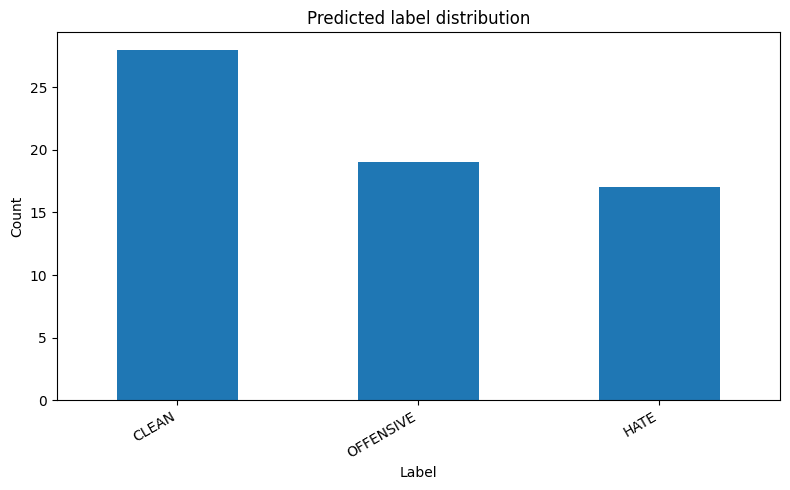

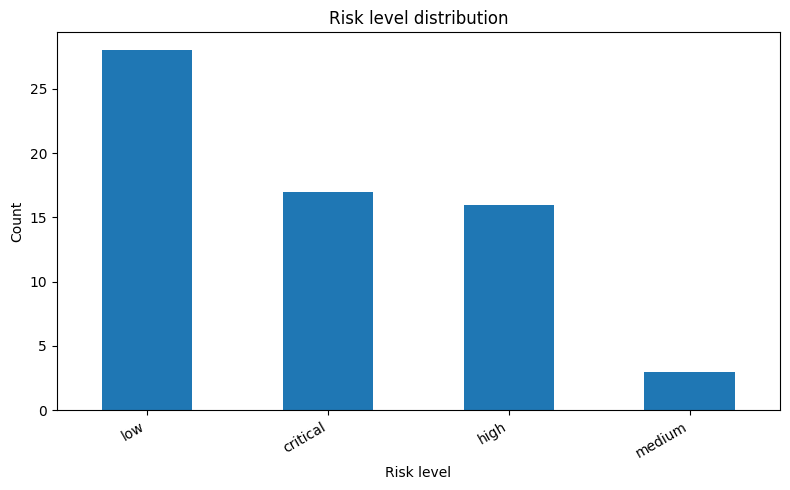

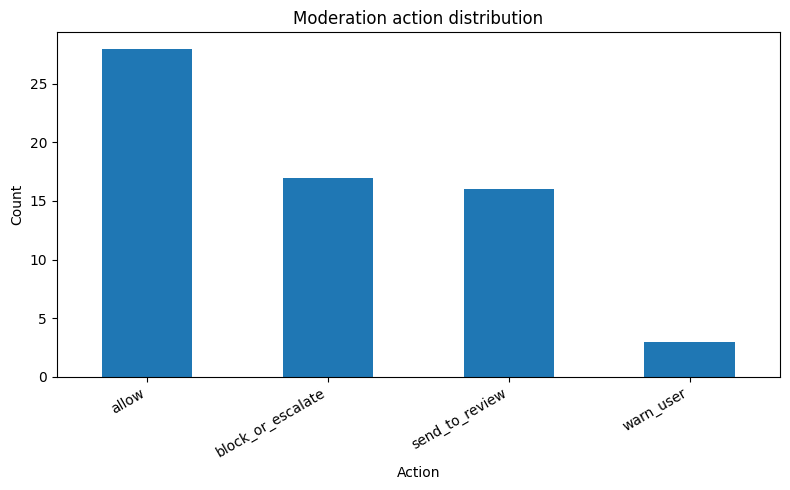

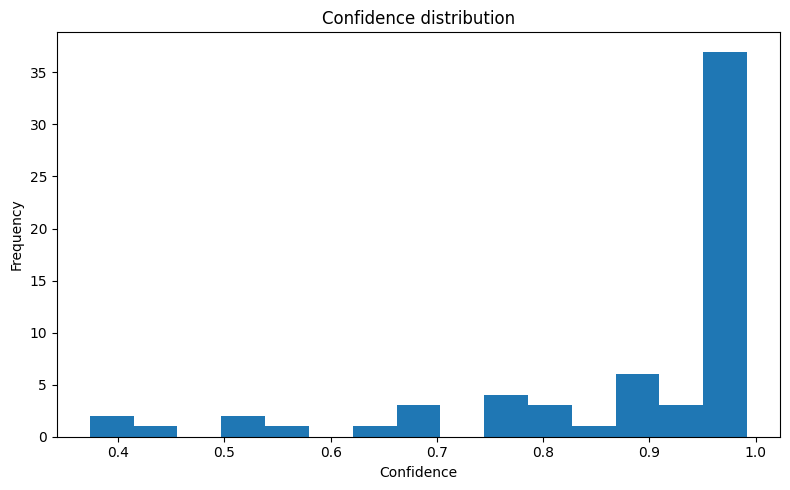

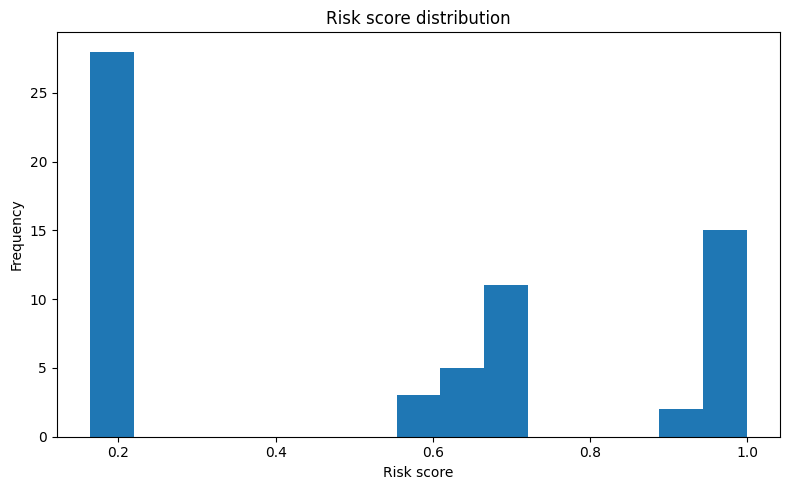

Saved figures:
- outputs/figures/note09/label_distribution.png
- outputs/figures/note09/risk_level_distribution.png
- outputs/figures/note09/action_distribution.png
- outputs/figures/note09/confidence_distribution.png
- outputs/figures/note09/risk_score_distribution.png


In [11]:
# 11. Save dashboard figures for Note 09 and README
plt.rcParams["figure.figsize"] = (8, 5)

figures = []

def save_bar(series, title, xlabel, ylabel, filename):
    counts = series.fillna("missing").astype(str).value_counts()
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=160)
    plt.show()
    plt.close()
    figures.append(path)

save_bar(moderation_df["predicted_label"], "Predicted label distribution", "Label", "Count", "label_distribution.png")
save_bar(moderation_df["risk_level"], "Risk level distribution", "Risk level", "Count", "risk_level_distribution.png")
save_bar(moderation_df["moderation_action"], "Moderation action distribution", "Action", "Count", "action_distribution.png")

ax = moderation_df["confidence"].plot(kind="hist", bins=15)
ax.set_title("Confidence distribution")
ax.set_xlabel("Confidence")
plt.tight_layout()
path = FIGURES_DIR / "confidence_distribution.png"
plt.savefig(path, dpi=160)
plt.show()
plt.close()
figures.append(path)

ax = moderation_df["risk_score"].plot(kind="hist", bins=15)
ax.set_title("Risk score distribution")
ax.set_xlabel("Risk score")
plt.tight_layout()
path = FIGURES_DIR / "risk_score_distribution.png"
plt.savefig(path, dpi=160)
plt.show()
plt.close()
figures.append(path)

print("Saved figures:")
for p in figures:
    print("-", p.relative_to(PROJECT_ROOT))

In [12]:
# 12. Write app configuration and moderation policy resources
app_model_config = {
    "project_name": "Robust and Explainable Vietnamese Toxic Comment Moderation System",
    "primary_model": "phobert_augmented_mixed",
    "primary_model_path": str(PHOBERT_MODEL_DIR.relative_to(PROJECT_ROOT)),
    "fallback_model": None,
    "default_app_mode": "full_phobert",
    "normalization_enabled": True,
    "normalization_source": NORMALIZATION_SOURCE,
    "span_explainer": "rule_based_deployable",
    "span_resource_candidates": [
        "outputs/resources/toxic_span_highlighter_rules.json",
        "outputs/resources/span_explainer_config.json",
        "outputs/resources/toxic_phrases_candidates_train.csv",
    ],
    "policy_mode": POLICY_MODE,
    "external_demo_cases": str(demo_cases_path.relative_to(PROJECT_ROOT)),
}

moderation_policy = {
    "description": "Transparent rule-based moderation policy built on top of classifier predictions, confidence, toxic span evidence, and normalization signal.",
    "risk_levels": {
        "low": {"range": [0.00, 0.30], "default_action": "allow"},
        "medium": {"range": [0.30, 0.60], "default_action": "warn_user"},
        "high": {"range": [0.60, 0.80], "default_action": "send_to_review"},
        "critical": {"range": [0.80, 1.00], "default_action": "block_or_escalate"},
    },
    "policy_modes": {
        "lenient": {"risk_adjustment": -0.05},
        "balanced": {"risk_adjustment": 0.00},
        "strict": {"risk_adjustment": 0.05},
    },
    "action_table": {
        "lenient": {"low": "allow", "medium": "allow_with_note", "high": "warn_user", "critical": "send_to_review"},
        "balanced": {"low": "allow", "medium": "warn_user", "high": "send_to_review", "critical": "block_or_escalate"},
        "strict": {"low": "allow", "medium": "send_to_review", "high": "hide_comment", "critical": "block_or_escalate"},
    },
    "important_note": "Risk score is a policy layer, not a directly learned model output. It should assist human moderation, not replace human judgment.",
}

app_config_path = RESOURCES_DIR / "app_model_config.json"
policy_path = RESOURCES_DIR / "moderation_policy.json"
write_json(app_model_config, app_config_path)
write_json(moderation_policy, policy_path)

print("Saved:")
print("-", app_config_path.relative_to(PROJECT_ROOT))
print("-", policy_path.relative_to(PROJECT_ROOT))

Saved:
- outputs/resources/app_model_config.json
- outputs/resources/moderation_policy.json


In [13]:
# 13. Write run config and model card summary
run_config = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "project_root": str(PROJECT_ROOT),
    "model_dir": str(PHOBERT_MODEL_DIR.relative_to(PROJECT_ROOT)),
    "normalization_source": NORMALIZATION_SOURCE,
    "policy_mode": POLICY_MODE,
    "batch_size": BATCH_SIZE,
    "normalize_input": NORMALIZE_INPUT,
    "external_comments_path": str(EXTERNAL_COMMENTS_PATH.relative_to(PROJECT_ROOT)),
    "num_external_comments": int(len(ext_df)),
    "num_toxic_phrases": int(len(phrases)),
    "device": str(device),
    "outputs": {
        "external_test_predictions": str(predictions_path.relative_to(PROJECT_ROOT)),
        "moderation_decisions": str(decisions_path.relative_to(PROJECT_ROOT)),
        "moderation_case_analysis": str(case_analysis_path.relative_to(PROJECT_ROOT)),
        "demo_cases": str(demo_cases_path.relative_to(PROJECT_ROOT)),
    },
    "interpretation": "Qualitative external moderation analysis; not an accuracy benchmark.",
}

run_config_path = RESULTS_DIR / "note09_run_config.json"
write_json(run_config, run_config_path)

model_card_md = f"""
# Note 09 Model Card Summary

## Purpose
This artifact integrates the Vietnamese toxic comment classifier, normalization, toxic span highlighting, and risk-based moderation decision into a deployable moderation pipeline.

## Primary classifier
- Model: PhoBERT augmented mixed
- Path: `{PHOBERT_MODEL_DIR.relative_to(PROJECT_ROOT)}`
- Labels: CLEAN, OFFENSIVE, HATE

## Explanation layer
The deployed explanation layer is rule-based and uses toxic phrase resources from Note 7 when available. It is designed for lightweight deployment and human-readable highlighting.

## Risk policy
Risk score is a transparent policy layer, not a learned model output. It combines predicted label, confidence, toxic span evidence, and normalization signal.

## External analysis
The external comments are qualitative demo cases. They should not be interpreted as a formal accuracy benchmark.

## Limitations
- Vietnamese slang and obfuscation evolve quickly.
- OFFENSIVE and HATE boundaries can be subjective.
- Toxic span highlighting is approximate.
- High-impact moderation decisions should include human review.
""".strip()

model_card_path = RESULTS_DIR / "model_card_summary.md"
model_card_path.write_text(model_card_md, encoding="utf-8")

print("Saved:")
print("-", run_config_path.relative_to(PROJECT_ROOT))
print("-", model_card_path.relative_to(PROJECT_ROOT))

Saved:
- outputs/results/note09/note09_run_config.json
- outputs/results/note09/model_card_summary.md


In [14]:
# 14. Final validation
expected_outputs = [
    EXTERNAL_COMMENTS_PATH,
    RESULTS_DIR / "external_test_predictions.csv",
    RESULTS_DIR / "moderation_decisions.csv",
    RESULTS_DIR / "moderation_case_analysis.csv",
    RESULTS_DIR / "demo_cases.csv",
    RESULTS_DIR / "note09_run_config.json",
    RESULTS_DIR / "model_card_summary.md",
    FIGURES_DIR / "label_distribution.png",
    FIGURES_DIR / "risk_level_distribution.png",
    FIGURES_DIR / "action_distribution.png",
    FIGURES_DIR / "confidence_distribution.png",
    FIGURES_DIR / "risk_score_distribution.png",
    RESOURCES_DIR / "app_model_config.json",
    RESOURCES_DIR / "moderation_policy.json",
    SRC_DIR / "inference.py",
    SRC_DIR / "span_explainer.py",
    SRC_DIR / "risk_scoring.py",
    SRC_DIR / "moderation.py",
    SRC_DIR / "app_utils.py",
]

missing = [p for p in expected_outputs if not p.exists()]
if missing:
    print("Missing outputs:")
    for p in missing:
        print("-", p)
    raise FileNotFoundError("Some Note 09 outputs are missing.")

print("All expected Note 09 outputs exist.")
print("\nMain files:")
for p in expected_outputs:
    print("-", p.relative_to(PROJECT_ROOT))

summary = {
    "rows": len(moderation_df),
    "label_distribution": moderation_df["predicted_label"].value_counts().to_dict(),
    "risk_level_distribution": moderation_df["risk_level"].value_counts().to_dict(),
    "action_distribution": moderation_df["moderation_action"].value_counts().to_dict(),
    "mean_confidence": float(moderation_df["confidence"].mean()),
    "mean_risk_score": float(moderation_df["risk_score"].mean()),
}
print("\nSummary:")
print(json.dumps(summary, ensure_ascii=False, indent=2))

print("\nNote 09 is complete. Next step: run app.py with Cloudflare/Colab and use demo_cases.csv for the dashboard.")

All expected Note 09 outputs exist.

Main files:
- data/external/external_comments.csv
- outputs/results/note09/external_test_predictions.csv
- outputs/results/note09/moderation_decisions.csv
- outputs/results/note09/moderation_case_analysis.csv
- outputs/results/note09/demo_cases.csv
- outputs/results/note09/note09_run_config.json
- outputs/results/note09/model_card_summary.md
- outputs/figures/note09/label_distribution.png
- outputs/figures/note09/risk_level_distribution.png
- outputs/figures/note09/action_distribution.png
- outputs/figures/note09/confidence_distribution.png
- outputs/figures/note09/risk_score_distribution.png
- outputs/resources/app_model_config.json
- outputs/resources/moderation_policy.json
- src/inference.py
- src/span_explainer.py
- src/risk_scoring.py
- src/moderation.py
- src/app_utils.py

Summary:
{
  "rows": 64,
  "label_distribution": {
    "CLEAN": 28,
    "OFFENSIVE": 19,
    "HATE": 17
  },
  "risk_level_distribution": {
    "low": 28,
    "critical": 17